In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
root_dir = r'C:/Users/owner/Desktop/model/Dataset'
classes = ['Calculus', 'Gingivitis', 'Mouth_Ulcer', 'Caries']

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
print("🔹 Step 1: Checking dataset split...")

already_split = all(
    os.path.exists(os.path.join(root_dir, split, cls)) and
    len(os.listdir(os.path.join(root_dir, split, cls))) > 0
    for split in ['train','val','test'] for cls in classes
)

if already_split:
    print("✅ Dataset already split. Skipping this step.")
else:
    print("⚡ Splitting dataset into train/val/test...")
    for split in ['train','val','test']:
        for cls in classes:
            os.makedirs(os.path.join(root_dir, split, cls), exist_ok=True)

    train_ratio = 0.7
    val_ratio = 0.15

    for cls in classes:
        src_path = os.path.join(root_dir, cls)
        all_images = os.listdir(src_path)
        np.random.shuffle(all_images)

        train_count = int(len(all_images) * train_ratio)
        val_count = int(len(all_images) * val_ratio)

        train_files = all_images[:train_count]
        val_files = all_images[train_count:train_count+val_count]
        test_files = all_images[train_count+val_count:]

        for file in train_files:
            shutil.copy(os.path.join(src_path, file), os.path.join(root_dir, 'train', cls, file))
        for file in val_files:
            shutil.copy(os.path.join(src_path, file), os.path.join(root_dir, 'val', cls, file))
        for file in test_files:
            shutil.copy(os.path.join(src_path, file), os.path.join(root_dir, 'test', cls, file))

    print("✅ Dataset splitted successfully!")

🔹 Step 1: Checking dataset split...
✅ Dataset already split. Skipping this step.


🖼️ Step: Displaying sample images from each class...


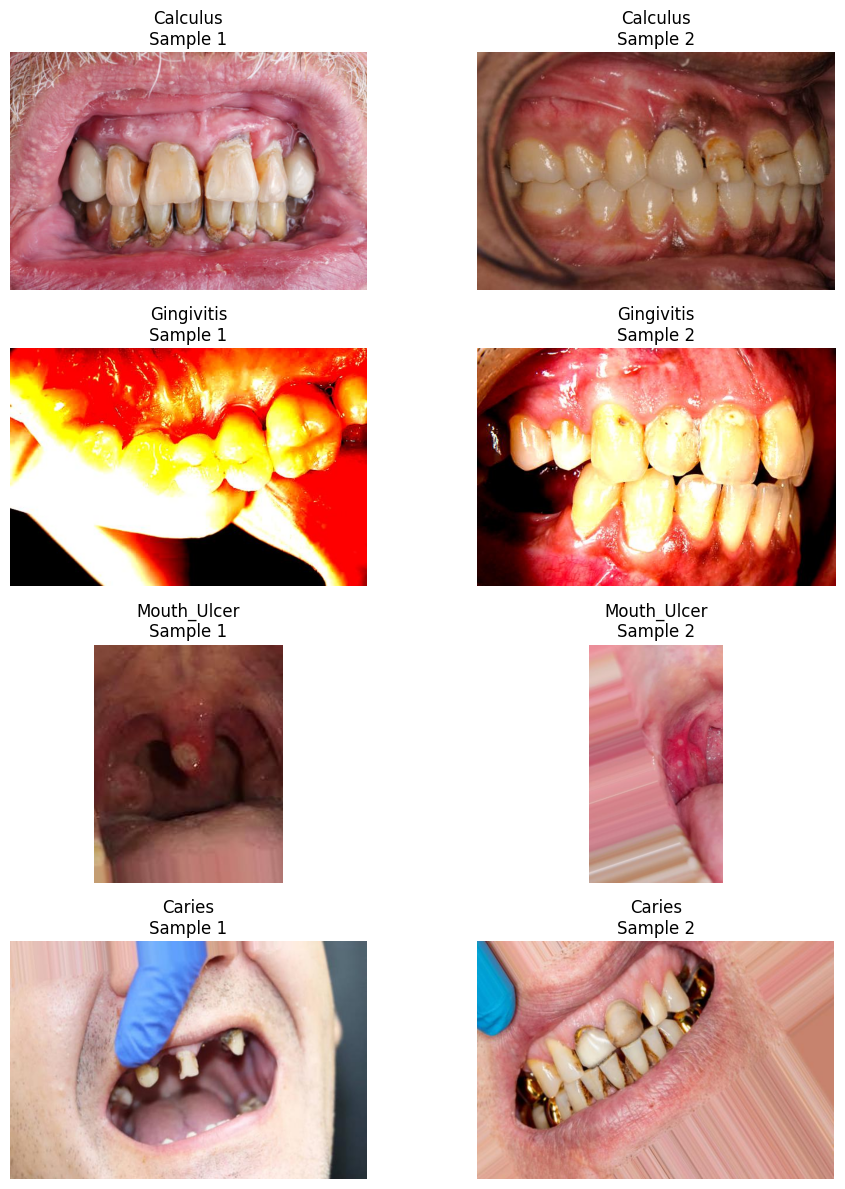

In [2]:

print("🖼️ Step: Displaying sample images from each class...")

base_dir = r'C:/Users/owner/Desktop/model/Dataset'
classes = ['Calculus', 'Gingivitis', 'Mouth_Ulcer', 'Caries']

num_samples = 2

plt.figure(figsize=(10, len(classes) * 3))

for i, class_dir in enumerate(classes):
    class_path = os.path.join(base_dir, class_dir)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        selected_images = random.sample(images, num_samples)
        
        for j, img_name in enumerate(selected_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{class_dir}\nSample {j+1}")
            plt.axis("off")

plt.tight_layout()
plt.show()

📊 Step 2: Visualizing dataset distribution...


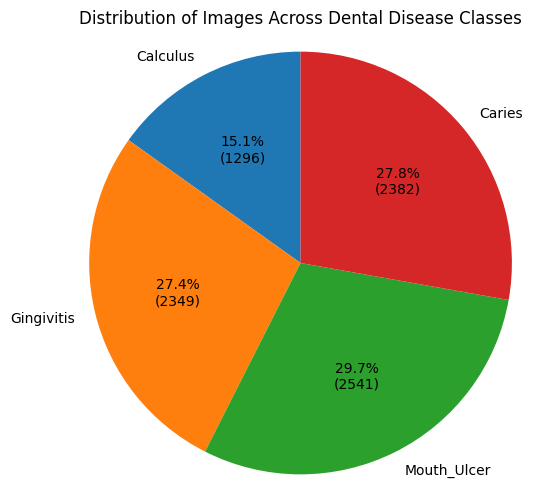

In [3]:
    
print("📊 Step 2: Visualizing dataset distribution...")
# Define dataset path
root_dir = r'C:/Users/owner/Desktop/model/Dataset'

# Dictionary to store number of images per class
image_count_per_class = {}

# Loop through each class
for class_name in ['Calculus', 'Gingivitis', 'Mouth_Ulcer', 'Caries']:
    class_path = os.path.join(root_dir, class_name)
    
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        image_count_per_class[class_name] = num_images

# Prepare data for pie chart
labels = list(image_count_per_class.keys())
sizes = list(image_count_per_class.values())

# Function to show percentage + number
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct=autopct_format(sizes), startangle=90)
plt.title('Distribution of Images Across Dental Disease Classes')
plt.axis('equal')
plt.show()

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [5]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(root_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(root_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(root_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5996 images belonging to 4 classes.
Found 1284 images belonging to 4 classes.
Found 1288 images belonging to 4 classes.


In [6]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation='softmax')
])

In [7]:
model.compile(
    optimizer=optimizers.Adam(3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training classifier head...")
model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator
)

Training classifier head...
Epoch 1/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.6910 - loss: 0.7549 - val_accuracy: 0.7998 - val_loss: 0.4411
Epoch 2/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.7887 - loss: 0.5013 - val_accuracy: 0.8302 - val_loss: 0.3774
Epoch 3/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.8184 - loss: 0.4302 - val_accuracy: 0.8248 - val_loss: 0.3733
Epoch 4/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.8336 - loss: 0.3862 - val_accuracy: 0.8637 - val_loss: 0.3124
Epoch 5/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.8432 - loss: 0.3598 - val_accuracy: 0.8598 - val_loss: 0.3012
Epoch 6/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8472 - loss: 0.3473 - val_accuracy: 0.8723 - val_loss: 0.2843
Epoch 7/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.8577 - loss: 0.3231 - val_accuracy: 0.8699 - val_loss: 0.2901
Epoch 8/12
188/188 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.86

In [8]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 520s 3s/step - accuracy: 0.8025 - loss: 0.4851 - val_accuracy: 0.8606 - val_loss: 0.2980
Epoch 2/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.8321 - loss: 0.3934 - val_accuracy: 0.8505 - val_loss: 0.3223
Epoch 3/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 2176s 12s/step - accuracy: 0.8452 - loss: 0.3652 - val_accuracy: 0.8590 - val_loss: 0.2969
Epoch 4/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.8551 - loss: 0.3432 - val_accuracy: 0.8660 - val_loss: 0.2757
Epoch 5/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 490s 3s/step - accuracy: 0.8594 - loss: 0.3169 - val_accuracy: 0.8723 - val_loss: 0.2677
Epoch 6/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.8641 - loss: 0.3125 - val_accuracy: 0.8769 - val_loss: 0.2589
Epoch 7/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.8778 - loss: 0.2810 - val_accuracy: 0.8731 - val_loss: 0.2593
Epoch 8/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 3679s 20s/step - accuracy: 0.8758 - loss: 0.2721 - val_

In [9]:
model.save('dental_v2.h5')
print("✅ Model saved!")

✅ Model saved!


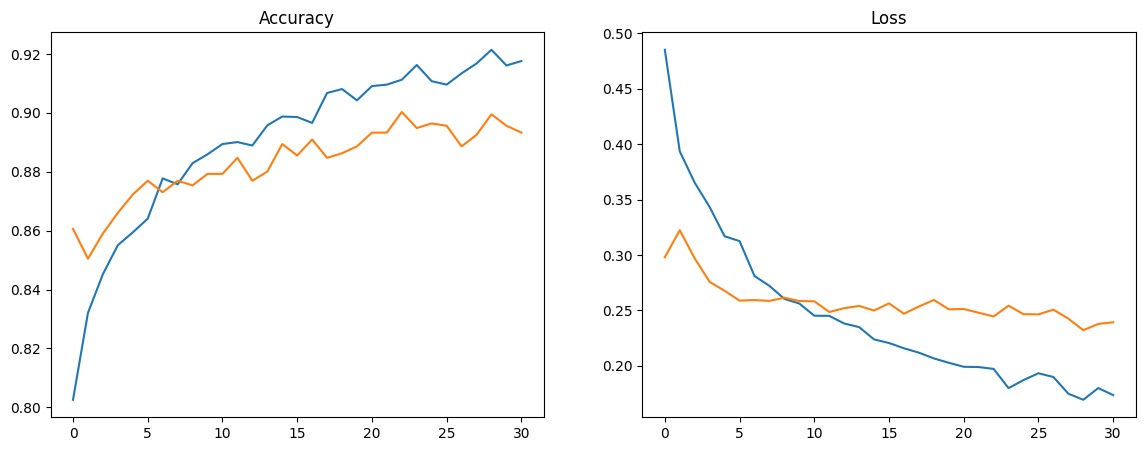

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'])
axes[0].plot(history.history['val_accuracy'])
axes[0].set_title('Accuracy')

axes[1].plot(history.history['loss'])
axes[1].plot(history.history['val_loss'])
axes[1].set_title('Loss')

plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 37s 899ms/step - accuracy: 0.8952 - loss: 0.2442
Test Accuracy: 89.52%
Test Loss: 0.2442


41/41 ━━━━━━━━━━━━━━━━━━━━ 40s 933ms/step
              precision    recall  f1-score   support

    Calculus       0.71      0.71      0.71       195
  Gingivitis       0.98      0.94      0.96       358
 Mouth_Ulcer       0.81      0.86      0.83       353
      Caries       1.00      0.98      0.99       382

    accuracy                           0.90      1288
   macro avg       0.87      0.87      0.87      1288
weighted avg       0.90      0.90      0.90      1288



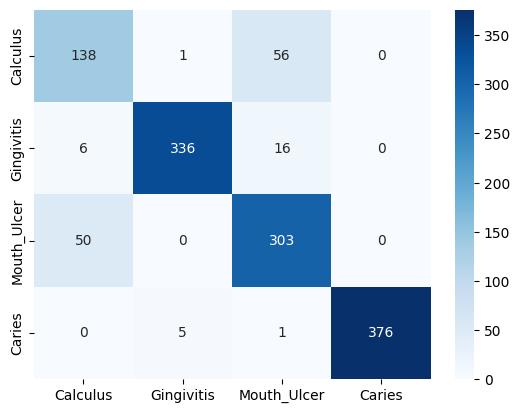

In [12]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=classes
))

cm = confusion_matrix(test_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.show()